# JAX waveform comparison

This companion fixes physical inputs and frequency grids, measures default diffGW differences without time/phase maximization, and proves that each original waveform, decompression and taper control restores exact bytes. The examples qualify these inputs and the recorded package sources; they do not survey each model's full physical domain.

## Setup

Use an installed PyCBC environment with JAX, diffGW, LALSuite, NumPy, SciPy, pandas and Matplotlib. Choose `cpu` or an available CUDA device below. All data are constructed in memory. Original validation controls execute isolated CPU workers and are intentionally slow.

In [1]:
import hashlib
import warnings
import importlib.metadata as metadata
from importlib.resources import files

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import diffgw
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio")
import lal
import lalsimulation

from pycbc import scheme
from pycbc.types import TimeSeries, FrequencySeries, zeros
from pycbc.types.array_jax import to_jax
from pycbc.waveform import (get_fd_waveform, get_waveform_filter,
                            get_two_pol_waveform_filter, utils)
from pycbc.waveform.compress import fd_decompress
from pycbc.waveform.decompress_jax import stage_batched_device_interp_jax

DEVICE = "cpu"
jax.config.update("jax_enable_x64", True)
plt.rcParams.update({"figure.figsize": (7, 3.3), "font.size": 10})
versions = {name: metadata.version(name) for name in
            ("numpy", "scipy", "jax", "jaxlib", "diffgw", "lalsuite")}
source_hashes = {
    name: hashlib.sha256(files(package).joinpath(name).read_bytes()).hexdigest()
    for package, name in [
        ("jaxwave", "approximants/taylorf2.py"),
        ("jaxwave", "approximants/imrphenomd.py"),
        ("jaxwave", "approximants/imrphenom_xas.py"),
        ("diffgw_core", "constants.py"),
        ("diffgw_core", "fits.py"),
        ("diffgw_core", "qnm_data.py")]
}
print("Versions:", versions)
print("Device platform:", jax.devices(DEVICE)[0].platform)
pd.DataFrame(source_hashes.items(), columns=["Provider source", "SHA256"])

Versions: {'numpy': '2.5.2', 'scipy': '1.16.3', 'jax': '0.11.1', 'jaxlib': '0.11.1', 'diffgw': '0.1.0', 'lalsuite': '7.26.15'}
Device platform: cpu


,Provider source,SHA256
0,approximants/taylorf2.py,ca4f77af732d55506d36f74eb1215c9c45b428078c754b...
1,approximants/imrphenomd.py,325077c8107b20dc39735529bc9a70f1b2da5f0d80d70b...
2,approximants/imrphenom_xas.py,ea97cadbf248d63db84f3c530e1cbd0d291c457848bb0a...
3,constants.py,6476c438213819c8a840825bc13c8cff95e98659383a04...
4,fits.py,a32843e13321bcfef2089acdefbdb6251cf1400f5b13b6...
5,qnm_data.py,3d1f9e8c5959dc75d3a25480b794e2b733c2076b8b292b...


## Fixed waveform inputs

The two polarizations use 30 and 20 solar masses, aligned spins 0.1 and −0.2, distance 100 Mpc, inclination 0.3 rad, orbital phase 0.2 rad, and a 2 Hz grid from 0 to 128 Hz with a 20 Hz lower cutoff. The original and default arrays have identical geometry and precision. `waveform` selects the corresponding original CPU function; it does not change the subsequent JAX calculations.

In [2]:
parameters = dict(mass1=30., mass2=20., spin1z=.1, spin2z=-.2,
                  distance=100., inclination=.3, coa_phase=.2,
                  delta_f=2., f_lower=20., f_final=128.)
comparisons, original_arrays, default_arrays = [], {}, {}
for approximant in ("TaylorF2", "IMRPhenomD", "IMRPhenomXAS"):
    request = dict(parameters, approximant=approximant)
    with scheme.CPUScheme():
        original = get_fd_waveform(**request)
    with scheme.JAXScheme(DEVICE):
        default = get_fd_waveform(**request)
        default_arrays[approximant] = default[0].numpy()
    with scheme.JAXScheme(DEVICE, reference_operations=("waveform",)) as context:
        native = get_fd_waveform(**request)
        for result, expected in zip(native, original, strict=True):
            assert result.numpy().tobytes() == expected.numpy().tobytes()
            assert to_jax(result).devices() == {context.jax_device}
            assert (result.dtype, result.shape, result.delta_f, result.epoch) == (
                expected.dtype, expected.shape, expected.delta_f, expected.epoch)
    for result, expected in zip(default, original, strict=True):
        assert (result.dtype, result.shape, result.delta_f, result.epoch) == (
            expected.dtype, expected.shape, expected.delta_f, expected.epoch)
    expected = original[0].numpy()
    actual = default_arrays[approximant]
    original_arrays[approximant] = expected
    mask = (expected != 0) & (actual != 0)
    ratio = actual[mask] / expected[mask]
    comparisons.append(dict(model=approximant, bins=len(expected),
        different_default_bins=np.count_nonzero(actual != expected),
        max_relative_amplitude_difference=np.max(np.abs(np.abs(ratio) - 1)),
        max_phase_difference_rad=np.max(np.abs(np.angle(ratio))),
        original_control_exact=True))
pd.DataFrame(comparisons)

,model,bins,different_default_bins,max_relative_amplitude_difference,max_phase_difference_rad,original_control_exact
0,TaylorF2,65,55,1.221245e-15,5.690330e-14,True
1,IMRPhenomD,65,55,2.686740e-14,4.974696e-13,True
2,IMRPhenomXAS,65,55,9.425793e-14,1.669176e-13,True


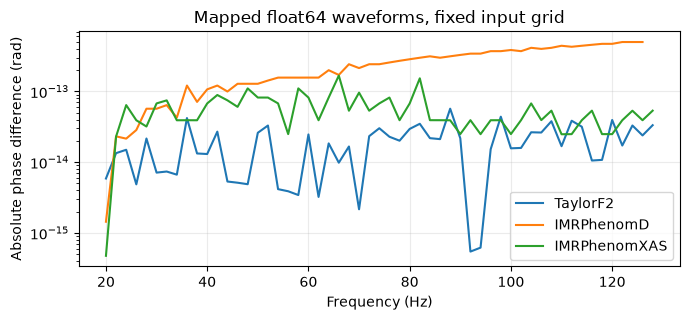

In [3]:
frequencies = np.arange(65) * parameters["delta_f"]
fig, ax = plt.subplots()
for approximant in original_arrays:
    expected, actual = original_arrays[approximant], default_arrays[approximant]
    mask = (expected != 0) & (actual != 0)
    error = np.abs(np.angle(actual[mask] / expected[mask]))
    ax.plot(frequencies[mask], np.maximum(error, np.finfo(float).tiny),
            label=approximant)
ax.set(xlabel="Frequency (Hz)", ylabel="Absolute phase difference (rad)",
       title="Mapped float64 waveforms, fixed input grid", yscale="log")
ax.grid(alpha=.25)
ax.legend()
fig.tight_layout()
plt.show()

## Original filter storage and metadata

Both public filter wrappers preserve the caller's output precision. These fixed-input checks compare all three FD models in complex64 and complex128, including grid, epoch, duration, selected device and shared output storage. Native LAL generation runs in this kernel's original library environment.

In [4]:
filters = []
for function in ("get_waveform_filter", "get_two_pol_waveform_filter"):
    for approximant in ("TaylorF2", "IMRPhenomD", "IMRPhenomXAS"):
        for dtype in (np.complex64, np.complex128):
            def evaluate():
                outputs = [zeros(65, dtype=dtype) for _ in
                           range(1 if function == "get_waveform_filter" else 2)]
                if function == "get_waveform_filter":
                    result = (get_waveform_filter(outputs[0], approximant=approximant,
                                                  **parameters),)
                else:
                    result = get_two_pol_waveform_filter(*outputs, None,
                        approximant=approximant, **parameters)
                return outputs, result
            with scheme.CPUScheme():
                _, original = evaluate()
            with scheme.JAXScheme(DEVICE, reference_operations=("waveform",)) as context:
                outputs, native = evaluate()
                for output, result, expected in zip(outputs, native, original, strict=True):
                    assert result._data is output._data
                    assert to_jax(result).devices() == {context.jax_device}
                    assert result.numpy().tobytes() == expected.numpy().tobytes()
                    assert (result.dtype, result.shape, result.delta_f, result.epoch,
                            result.chirp_length, result.length_in_time) == (
                        expected.dtype, expected.shape, expected.delta_f, expected.epoch,
                        expected.chirp_length, expected.length_in_time)
            filters.append(dict(function=function, model=approximant,
                storage=np.dtype(dtype).name, original_control_exact=True))
pd.DataFrame(filters)

,function,model,storage,original_control_exact
0,get_waveform_filter,TaylorF2,complex64,True
1,get_waveform_filter,TaylorF2,complex128,True
2,get_waveform_filter,IMRPhenomD,complex64,True
3,get_waveform_filter,IMRPhenomD,complex128,True
4,get_waveform_filter,IMRPhenomXAS,complex64,True
5,get_waveform_filter,IMRPhenomXAS,complex128,True
6,get_two_pol_waveform_filter,TaylorF2,complex64,True
7,get_two_pol_waveform_filter,TaylorF2,complex128,True
8,get_two_pol_waveform_filter,IMRPhenomD,complex64,True
9,get_two_pol_waveform_filter,IMRPhenomD,complex128,True


## Phase conventions and arithmetic

Original Phenom `f_ref=0` resolves to the lower frequency; the frequency-sequence API resolves it to the first requested sample. diffGW's omitted reference frequency instead uses its coalescence convention. The adapter therefore passes the resolved reference explicitly. This control deliberately omits that mapping, showing the resulting constant phase offset. No phase/time fit is applied to the reported default waveforms.

In [5]:
conventions = []
for approximant in ("IMRPhenomD", "IMRPhenomXAS"):
    plus, _ = diffgw.get_fd_waveform(
        approximant, backend="jax", sample_frequencies=jnp.asarray(frequencies),
        dtype=jnp.float64, mass1=30., mass2=20., spin1z=.1, spin2z=-.2,
        distance=100., inclination=.3, phic=.2, f_lower=20.)
    expected = original_arrays[approximant]
    mask = expected != 0
    offset = np.unwrap(np.angle(np.asarray(plus)[mask] / expected[mask]))
    conventions.append(dict(model=approximant,
        raw_provider_phase_offset_rad=float(offset[0]),
        offset_spread_rad=float(np.ptp(offset)),
        mapped_max_phase_difference_rad=comparisons[
            ("TaylorF2", "IMRPhenomD", "IMRPhenomXAS").index(approximant)
        ]["max_phase_difference_rad"]))
    assert np.ptp(offset) < 1e-9
pd.DataFrame(conventions)

,model,raw_provider_phase_offset_rad,offset_spread_rad,mapped_max_phase_difference_rad
0,IMRPhenomD,1.831128,5.113687e-13,4.974696e-13
1,IMRPhenomXAS,-0.214732,1.881550e-13,1.669176e-13


TaylorF2's orbital-phase mapping adds π/2 to account for the amplitude sign. After this convention mapping, the comparison still need not be byte-identical: independent libraries evaluate the post-Newtonian coefficients and their arithmetic separately. The public coefficient routines below expose one concrete boundary without implementing a waveform here.

For 3PN, diffGW keeps `log(4*v)` in the phase expression; the original public phasing coefficients put `log(4)` into the constant coefficient. Folding this constant into the same basis exposes small separately rounded coefficient differences. Even the logarithm identity itself can round differently. Trigonometric evaluation and complex64 storage add further numerical boundaries; this example does not claim any one boundary explains every bin of every model.

In [6]:
from jaxwave.approximants.taylorf2 import TaylorF2

original_coefficients = lalsimulation.SimInspiralTaylorF2AlignedPhasing(
    30 * lal.MSUN_SI, 20 * lal.MSUN_SI, .1, -.2, lal.CreateDict())
provider_coefficients = TaylorF2.phase_coefficients(
    jnp.asarray(30.), jnp.asarray(20.), jnp.asarray(.1), jnp.asarray(-.2),
    spin_order=7)
indices = [0, 2, 3, 4, 5, 6, 7]
provider_values = np.asarray(provider_coefficients)[[0, 1, 2, 3, 4, 6, 8]].copy()
provider_values[5] += float(provider_coefficients[7]) * np.log(4.)
original_values = np.asarray(original_coefficients.v)[indices] / original_coefficients.v[0]
assert np.allclose(provider_values, original_values, rtol=1e-13, atol=1e-12)
pd.DataFrame({"PN coefficient index": indices, "Original": original_values,
              "diffGW, common log basis": provider_values,
              "Difference": provider_values - original_values})

,PN coefficient index,Original,"diffGW, common log basis",Difference
0,0,1.000000,1.000000,0.000000e+00
1,2,6.380688,6.380688,0.000000e+00
2,3,-50.714816,-50.714816,0.000000e+00
3,4,45.465093,45.465093,0.000000e+00
4,5,157.794480,157.794480,-2.842171e-14
5,6,-1099.603860,-1099.603860,-2.273737e-13
6,7,1155.889186,1155.889186,-2.273737e-13


In [7]:
velocity = np.array([.1, .15, .2, .3], dtype=np.float64)
direct_log = np.log(4 * velocity)
separate_log = np.log(velocity) + np.log(4.)
pd.DataFrame({"v": velocity, "log(4*v)": direct_log,
              "log(v) + log(4)": separate_log,
              "Floating-point difference": direct_log - separate_log})

,v,log(4*v),log(v) + log(4),Floating-point difference
0,0.10,-0.916291,-0.916291,-1.110223e-16
1,0.15,-0.510826,-0.510826,0.000000e+00
2,0.20,-0.223144,-0.223144,0.000000e+00
3,0.30,0.182322,0.182322,1.387779e-16


## PhenomD: hold the fits and phase terms fixed

The [original PhenomD implementation](https://lscsoft.docs.ligo.org/lalsuite/7.26/lalsimulation/_l_a_l_sim_i_m_r_phenom_d__internals_8c_source.html) nests its Table V polynomial products. The installed provider expands them into powers of the spin coordinate. This first comparison uses the **same coefficients, physical inputs and JAX backend**, changing only the product grouping. Thus a difference identifies arithmetic grouping rather than a changed fit or waveform convention. The complete original PyCBC/LAL waveforms above remain the scientific oracle; evaluating the original expression on JAX is an isolation experiment, not the original-path selector.

In [8]:
from jaxwave.approximants.imrphenomd import IMRPhenomD, TABLE_V_COEFFS
from jaxwave.conversions import spin_combinations

m1, m2, spin1, spin2 = [jnp.asarray(v, dtype=jnp.float64)
                       for v in (30., 20., .1, -.2)]
eta = m1 * m2 / (m1 + m2)**2
_, _, chi_pn, _ = spin_combinations(m1, m2, spin1, spin2)
xi, eta2 = chi_pn - 1., eta * eta

def original_fit_grouping(name):
    c = jnp.asarray(TABLE_V_COEFFS[name], dtype=jnp.float64)
    return (c[0] + c[1] * eta
            + (c[2] + c[3] * eta + c[4] * eta2
               + (c[5] + c[6] * eta + c[7] * eta2) * xi
               + (c[8] + c[9] * eta + c[10] * eta2) * xi * xi) * xi)

fit_comparison = []
for name in ("rho1", "rho2", "rho3", "sigma1", "sigma2", "sigma3", "sigma4"):
    expanded = IMRPhenomD.eval_table_v(name, eta, chi_pn)
    grouped = original_fit_grouping(name)
    fit_comparison.append(dict(coefficient=name, expanded=float(expanded),
        original_grouping_on_jax=float(grouped), difference=float(expanded-grouped)))
pd.DataFrame(fit_comparison)

,coefficient,expanded,original_grouping_on_jax,difference
0,rho1,4925.865128,4925.865128,-2.728484e-12
1,rho2,-49932.134124,-49932.134124,1.455192e-11
2,rho3,121535.377001,121535.377001,2.910383e-11
3,sigma1,-60.596400,-60.596400,5.684342e-14
4,sigma2,-1184.859084,-1184.859084,0.000000e+00
5,sigma3,2405.626967,2405.626967,1.455192e-11
6,sigma4,3393.797578,3393.797578,-1.455192e-11


Original PhenomD caches a sixth root of dimensionless frequency `Mf`, builds its powers by multiplication, and combines them with cached powers of π. The provider forms `(π*Mf)**(1/3)` directly. We hold the calibrated PN coefficients fixed and evaluate the same PN phase with these two velocities, including the same 20 Hz phase reference. This shows how root rounding reaches phase before any polarization or storage conversion.

The peak-slope comparison holds its fitted coefficients fixed too. It reports equality when the algebraic forms agree at these inputs; it does not assume every rewrite introduces a difference. Continuity matching, reference subtraction, solver rounding and trigonometric evaluation can add further boundaries. These isolated effects are not additive error bars or a decomposition of every final waveform bin.

In [9]:
positive_frequencies = jnp.asarray(frequencies[frequencies >= 20.])
mf = (m1 + m2) * lal.MTSUN_SI * positive_frequencies
velocity_direct = (jnp.pi * mf)**(1./3.)
sixth_mf, sixth_pi = mf**(1./6.), jnp.asarray(np.pi)**(1./6.)
velocity_cached = (sixth_mf * sixth_mf) * (sixth_pi * sixth_pi)
calibrated = TaylorF2.phase_coefficients(
    m1, m2, spin1, spin2, phenom_d_calibration=True)

def held_pn_phase(v):
    c0, c2, c3, c4, c5, c5log, c6, c6log, c7 = calibrated[:9]
    terms = (c0 + c2*v**2 + c3*v**3 + c4*v**4
             + (c5+c5log*jnp.log(v))*v**5
             + (c6+c6log*jnp.log(4*v))*v**6 + c7*v**7)
    return (3./(128.*eta*v**5)) * terms

phase_direct, phase_cached = [held_pn_phase(v)
                              for v in (velocity_direct, velocity_cached)]
reference_difference = ((phase_direct-phase_direct[0])
                        - (phase_cached-phase_cached[0]))
_, _, ring, damping = IMRPhenomD.remnant_properties(m1, m2, spin1, spin2)
peak = IMRPhenomD.amplitude_peak_frequency(ring, damping,
    IMRPhenomD.eval_table_v("gamma2", eta, chi_pn),
    IMRPhenomD.eval_table_v("gamma3", eta, chi_pn))
a = [IMRPhenomD.eval_table_v("alpha"+str(i), eta, chi_pn) for i in range(1, 6)]
slope_direct = IMRPhenomD.compute_slope_peak(m1, m2, spin1, spin2)
slope_original_form = (a[0] + a[1]/(peak*peak) + a[2]/peak**.25
    + a[3]/(damping*(1.+(peak-a[4]*ring)**2/(damping*damping))))*(1./eta)
pd.DataFrame([dict(
    different_velocity_bins=int(jnp.count_nonzero(velocity_direct != velocity_cached)),
    max_velocity_difference=float(jnp.max(jnp.abs(velocity_direct-velocity_cached))),
    max_referenced_pn_phase_difference_rad=float(jnp.max(jnp.abs(reference_difference))),
    held_peak_slope_difference=float(slope_direct-slope_original_form))])

,different_velocity_bins,max_velocity_difference,max_referenced_pn_phase_difference_rad,held_peak_slope_difference
0,30,1.110223e-16,1.403322e-13,0.0


## PhenomXAS: root caching and matrix coordinates

The [original PhenomX fit implementation](https://lscsoft.docs.ligo.org/lalsuite/7.26/lalsimulation/_l_a_l_sim_i_m_r_phenom_x__internals_8c_source.html) builds the inspiral phase-fit columns with `cbrt(f)` and its square. The provider evaluates the fractional powers separately. The first experiment reconstructs the **actual four inspiral fit inputs** for this binary, verifies the resulting calibrated coefficients against the provider state, and changes only those matrix columns while holding the right-hand side and JAX solver fixed.

For intermediate phase, the provider uses inverse powers of `Mf`; the original scales them by powers of the ringdown frequency and rescales the solved coefficients. The second experiment holds one fitted polynomial target fixed and changes only matrix coordinates. The condition number measures sensitivity of a solve to rounding, not a waveform error estimate. The original implementation also uses GSL LU routines rather than JAX's solver, a separate linear-algebra boundary. Neither experiment replaces the original waveform comparison.

In [10]:
from jaxwave.approximants.imrphenom_xas import XASCarrierState, XASParameterFits

carrier = XASCarrierState(30., 20., .1, -.2, f_ref=20.)
upper = 1.02 * XASParameterFits.fit_f_meco(eta, spin1, spin2)
lower = jnp.ones_like(upper) * .0026
width = upper-lower
collocation = jnp.stack([lower, lower+.25*width, lower+.75*width, upper])
v3 = XASParameterFits.fit_ins_phase_v3_104(eta, spin1, spin2)
rhs = jnp.stack([
    v3 + XASParameterFits.fit_ins_phase_d13_104(eta, spin1, spin2),
    v3 + XASParameterFits.fit_ins_phase_d23_104(eta, spin1, spin2), v3,
    v3 + XASParameterFits.fit_ins_phase_d43_104(eta, spin1, spin2)])
separate = jnp.stack([jnp.ones_like(collocation), collocation**(1./3.),
                     collocation**(2./3.), collocation], axis=-1)
root = jnp.cbrt(collocation)
cached = jnp.stack([jnp.ones_like(root), root, root*root, collocation], axis=-1)
coefficients = jnp.linalg.solve(separate, rhs)
cached_coefficients = jnp.linalg.solve(cached, rhs)
calibration = -5./(128.*np.pi**(5./3.))
assert np.asarray(coefficients*calibration)[1:].tobytes() == np.array(
    [carrier.sig2, carrier.sig3, carrier.sig4]).tobytes()

lower, upper = carrier.f_trans_phase, carrier.f_join_rd
width = upper-lower
collocation = jnp.stack([lower,
    lower+.5*(1.-1./np.sqrt(2.))*width, lower+.5*width,
    lower+.5*(1.+1./np.sqrt(2.))*width, upper])
unscaled = jnp.stack([collocation**(-k) for k in range(5)], axis=-1)
held = jnp.stack([carrier.b0_val, carrier.b1_val, carrier.b2_val,
                 carrier.b3_val, carrier.b4_val])
held_rhs = unscaled @ held
column_scale = carrier.f_rd**jnp.arange(5)
scaled = unscaled * column_scale
solution = jnp.linalg.solve(unscaled, held_rhs)
rescaled_solution = jnp.linalg.solve(scaled, held_rhs) * column_scale
pd.DataFrame([
    dict(boundary="Inspiral root/power columns", provider_state_verified=True,
         maximum_coefficient_difference=float(jnp.max(jnp.abs(
             coefficients-cached_coefficients)))),
    dict(boundary="Intermediate matrix coordinates", provider_state_verified=None,
         maximum_coefficient_difference=float(jnp.max(jnp.abs(solution-rescaled_solution))),
         condition_before=np.linalg.cond(np.asarray(unscaled)),
         condition_after=np.linalg.cond(np.asarray(scaled)))])

,boundary,provider_state_verified,maximum_coefficient_difference,condition_before,condition_after
0,Inspiral root/power columns,True,5.640322e-08,NaN,NaN
1,Intermediate matrix coordinates,None,1.337952e-11,1.291610e+09,151537.41862


## PhenomXAS amplitude: hold the polynomial fixed

The provider evaluates its intermediate-amplitude denominator in normalized coordinate `u=(Mf-f1)/(f4-f1)`. The [original expression](https://lscsoft.docs.ligo.org/lalsuite/7.26/lalsimulation/_l_a_l_sim_i_m_r_phenom_x__intermediate_8c_source.html) evaluates it in `Mf`. We algebraically convert the same provider polynomial into that basis and supply it to LAL's public analytical amplitude routine. The numerator is held byte-identical. Any difference here comes from the basis conversion and evaluation sequence, before different collocation-coefficient construction or physical amplitude normalization.

This is a boundary experiment using held coefficients, not another complete-waveform oracle. The full original PyCBC/LAL `waveform` control above tests that oracle directly.

In [11]:
from numpy.polynomial import Polynomial

normalized_coefficients = np.array([float(getattr(carrier, "c"+str(i)+"_amp"))
                                    for i in range(5)])
f1, f4 = float(carrier.f1_col), float(carrier.f4_col)
width = f4-f1
absolute_coefficients = Polynomial(normalized_coefficients)(
    Polynomial([-f1/width, 1./width])).coef
middle = mf[(mf > f1) & (mf <= f4)]
u = (middle-f1)/width
c = normalized_coefficients
normalized_denominator = c[0] + u*(c[1] + u*(c[2] + u*(c[3] + u*c[4])))
numerator = middle**(7./6.)
normalized_amplitude = np.asarray(numerator/normalized_denominator)
original_expression_amplitude = np.array([
    lalsimulation.SimIMRPhenomXIntermediateAmplitude22AnsatzAnalytical(
        float(f), float(power), *absolute_coefficients, 0.)
    for f, power in zip(middle, numerator, strict=True)])
pd.DataFrame([dict(bins=len(middle),
    different_bins=np.count_nonzero(normalized_amplitude != original_expression_amplitude),
    max_relative_difference=np.max(np.abs(
        normalized_amplitude/original_expression_amplitude-1.)))])

,bins,different_bins,max_relative_difference
0,10,9,4.440892e-16


## Independent decompression control

The optional device-linear path interpolates amplitude and phase in the output precision and evaluates sine/cosine per output bin. The original compiled linear path uses double intermediate slopes and advances a complex rotation recurrence, periodically reseeding it with sine/cosine. These are different rounding sequences for the same interpolation. Selecting `decompress` restores the original compiled kernel and preserves the selected device. Both single and double precision are checked.

In [12]:
decompression = []
for real_dtype, complex_dtype in ((np.float32, np.complex64),
                                 (np.float64, np.complex128)):
    knots = np.array([0., 1.25, 3.5, 7.25], dtype=real_dtype)
    amplitude = np.array([.4, .8, .3, .9], dtype=real_dtype)
    phase = np.array([-.4, .3, -.7, 1.1], dtype=real_dtype)
    with scheme.CPUScheme():
        original = fd_decompress(amplitude, phase, knots, df=.5, f_lower=1.5)
    arguments = ([amplitude], [phase], [knots], [3], [len(original)], [4],
                 .5, len(original))
    with scheme.JAXScheme(DEVICE):
        _, device_linear = stage_batched_device_interp_jax(
            *arguments, dtype=complex_dtype)
    with scheme.JAXScheme(DEVICE, reference_operations=("decompress",)) as context:
        _, native = stage_batched_device_interp_jax(*arguments, dtype=complex_dtype)
        assert np.asarray(native[0]).tobytes() == original.numpy().tobytes()
        assert native.devices() == {context.jax_device}
    difference = np.asarray(device_linear[0]) - original.numpy()
    decompression.append(dict(dtype=np.dtype(complex_dtype).name,
        different_default_bins=np.count_nonzero(difference),
        max_absolute_difference=np.max(np.abs(difference)),
        original_control_exact=True))
pd.DataFrame(decompression)

,dtype,different_default_bins,max_absolute_difference,original_control_exact
0,complex64,8,6.664002e-08,True
1,complex128,8,3.510833e-16,True


## Independent taper controls

Default tapers calculate a periodic Kaiser window on device, including the modified Bessel function and subsequent multiplication. The original SciPy window is float64. The double-precision examples below have the same window definition and output-copy contract, and independently select `td_taper` or `fd_taper`. The original single-precision API may reject multiplication by its float64 window; its validation route preserves that error.

In [13]:
tapers = []
values = np.linspace(1., 2., 64)
for operation in ("td_taper", "fd_taper"):
    def source():
        return (TimeSeries(values, delta_t=.25, epoch=0)
                if operation == "td_taper" else
                FrequencySeries(values.astype(np.complex128), delta_f=.25))
    with scheme.CPUScheme():
        original = getattr(utils, operation)(source(), 2, 6)
    with scheme.JAXScheme(DEVICE):
        default = getattr(utils, operation)(source(), 2, 6)
    with scheme.JAXScheme(DEVICE, reference_operations=(operation,)) as context:
        input_series = source()
        native = getattr(utils, operation)(input_series, 2, 6)
        assert native is not input_series
        assert native.numpy().tobytes() == original.numpy().tobytes()
        assert to_jax(native).devices() == {context.jax_device}
        np.testing.assert_array_equal(input_series.numpy(), values)
        assert native._epoch == original._epoch
    difference = default.numpy() - original.numpy()
    tapers.append(dict(operation=operation,
        different_default_bins=np.count_nonzero(difference),
        max_absolute_difference=np.max(np.abs(difference)),
        original_control_exact=True))
pd.DataFrame(tapers)

,operation,different_default_bins,max_absolute_difference,original_control_exact
0,td_taper,6,2.220446e-16,True
1,fd_taper,6,2.220446e-16,True


## Checks

Every original-control assertion above compares sample bytes and relevant metadata against original CPU calls made outside `JAXScheme`. The selector names are independent: `waveform`, `decompress`, `td_taper` and `fd_taper`. The default remains diffGW synthesis and the selected JAX numerical paths. Source hashes make the measured provider implementation identifiable; updated libraries, devices and compiler versions can change the small default differences.